In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from itertools import combinations
from pycaret.datasets import get_data
import matplotlib.pyplot as plt

import pycaret.datasets as datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from tqdm import tqdm

import seaborn as sns

In [2]:
def get_dataset(dataset_name):
    """Get dataset."""

    target_name = "SalePrice"
    df = get_data(dataset_name, verbose=False).reset_index(drop=True)
    X, y = df.drop(target_name, axis=1), df[target_name]
    # y = y.replace({yval: binval for yval, binval in zip(y.value_counts().index, [0,1])}).iloc[:,0]
    num_features = X.columns[X.apply(is_numeric)].tolist()
    cat_features = [c for c in X.columns if c not in num_features]
    X[cat_features] = X[cat_features].fillna({feature: "NULL" for feature in cat_features})
    return df, X, y, num_features, cat_features


def is_numeric(x):
    """Check whether an object is numeric."""
    try:
        x + 0
        return True
    except:
        return False


def float2kdollars(value, tick_number=None):
    return f"$ {int(round(value / 1000))}{'k' if abs(value) > 0 else ''}"


In [3]:
random_state = 4

datasets = get_data(verbose=False)

df, X_full, y_full, num_features, cat_features = get_dataset("house")

X_full[["square feet", "overall condition"]] = X_full[["GrLivArea","OverallCond"]]

X = X_full[["square feet"]]
y = y_full

regr = OLS(y, add_constant(X)).fit()
regr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     1471.
Date:                Tue, 15 Oct 2024   Prob (F-statistic):          4.52e-223
Time:                        20:05:29   Log-Likelihood:                -18035.
No. Observations:                1460   AIC:                         3.607e+04
Df Residuals:                    1458   BIC:                         3.608e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1.857e+04   4480.755      4.144      0.000    9779.612    2.74e+04
square feet   107.1304      2.794     38.348      0.000     101.650     112.610
==============================================================================
Omnibus:                      261.166   Durbin-Watson:                   2.025
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3432.287
Skew:                           0.410   Prob(JB):                         0.00
Kurtosis:                      10.467   Cond. No.                     4.90e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.9e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [4]:
df[["square feet", "overall condition"]] = df[["GrLivArea","OverallCond"]]
#df = df[['square feet','overall condition','SalePrice','LotFrontage','LotArea']]
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,square feet,overall condition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,2,2008,WD,Normal,208500,1710,5
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,5,2007,WD,Normal,181500,1262,8
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,9,2008,WD,Normal,223500,1786,5
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,2,2006,WD,Abnorml,140000,1717,5
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,12,2008,WD,Normal,250000,2198,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,8,2007,WD,Normal,175000,1647,5
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,MnPrv,NaN,0,2,2010,WD,Normal,210000,2073,6
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,GdPrv,Shed,2500,5,2010,WD,Normal,266500,2340,9
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,4,2010,WD,Normal,142125,1078,6


In [8]:
data = df[['square feet','overall condition','SalePrice','LotArea']]

In [9]:
data

,square feet,overall condition,SalePrice,LotArea
0,1710,5,208500,8450
1,1262,8,181500,9600
2,1786,5,223500,11250
3,1717,5,140000,9550
4,2198,5,250000,14260
...,...,...,...,...
1455,1647,5,175000,7917
1456,2073,6,210000,13175
1457,2340,9,266500,9042
1458,1078,6,142125,9717


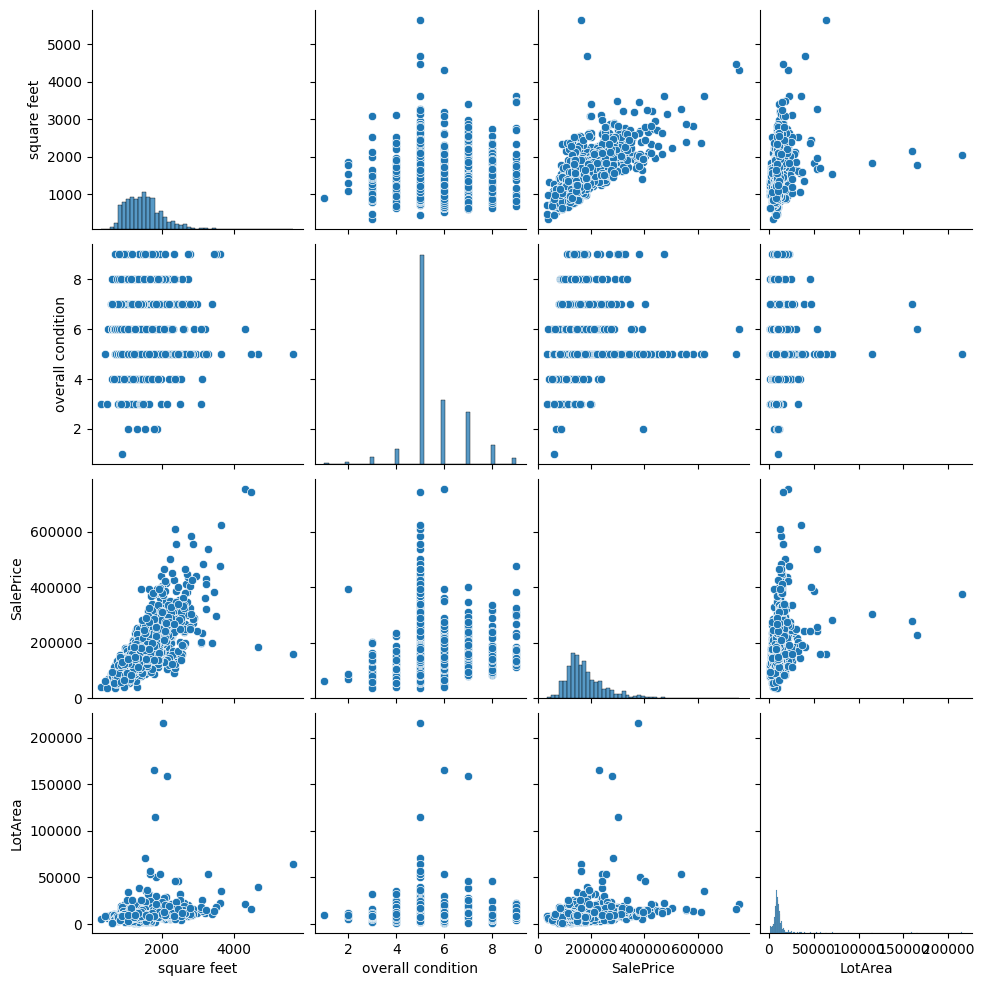

In [10]:
# Create the default pairplot
sns.pairplot(data)
plt.show()

In [11]:
X = df[['square feet','overall condition','LotArea']]
y = df["SalePrice"]
regr = OLS(y, add_constant(X)).fit()
bic4 = regr.bic
likelihood4 = np.exp(-bic4/2)
regr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.509
Model:                            OLS   Adj. R-squared:                  0.508
Method:                 Least Squares   F-statistic:                     503.3
Date:                Tue, 15 Oct 2024   Prob (F-statistic):          2.40e-224
Time:                        20:06:59   Log-Likelihood:                -18025.
No. Observations:                1460   AIC:                         3.606e+04
Df Residuals:                    1456   BIC:                         3.608e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              2.611e+04   8872.840      2.943      0.003    8704.656    4.35e+04
square feet         103.5331      2.887     35.864      0.000      97.870     109.196
overall condition -1628.6774   1315.194     -1.238      0.216   -4208.556     951.201
LotArea               0.6648      0.152      4.388      0.000       0.368       0.962
==============================================================================
Omnibus:                      264.459   Durbin-Watson:                   2.025
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4277.556
Skew:                           0.328   Prob(JB):                         0.00
Kurtosis:                      11.360   Cond. No.                     8.92e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.92e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [13]:
from mpmath import mp
mp.dps = 50
class BMA:
    
    def __init__(self, y, X, **kwargs):
        # Setup the basic variables.
        self.y = y
        self.X = X
        self.names = list(X.columns)
        self.nRows, self.nCols = np.shape(X)
        self.likelihoods = mp.zeros(self.nCols,1)
        self.likelihoods_all = {}
        self.coefficients_mp = mp.zeros(self.nCols,1)
        self.coefficients = np.zeros(self.nCols)
        self.probabilities = np.zeros(self.nCols)
        # Check the max model size. (Max number of predictor variables to use in a model.)
        # This can be used to reduce the runtime but not doing an exhaustive sampling.
        if 'MaxVars' in kwargs.keys():
            self.MaxVars = kwargs['MaxVars']
        else:
            self.MaxVars = self.nCols  
        # Prepare the priors if they are provided.
        # The priors are provided for the individual regressor variables.
        # The prior for a model is the product of the priors on the variables in the model.
        if 'Priors' in kwargs.keys():
            if np.size(kwargs['Priors']) == self.nCols:
                self.Priors = kwargs['Priors']
            else:
                print("WARNING: Provided priors error.  Using equal priors instead.")
                print("The priors should be a numpy array of length equal tot he number of regressor variables.")
                self.Priors = np.ones(self.nCols)  
        else:
            self.Priors = np.ones(self.nCols)  
        if 'Verbose' in kwargs.keys():
            self.Verbose = kwargs['Verbose'] 
        else:
            self.Verbose = False 
        if 'RegType' in kwargs.keys():
            self.RegType = kwargs['RegType'] 
        else:
            self.RegType = 'LS' 
        
    def fit(self):
        # Perform the Bayesian Model Averaging
        
        # Initialize the sum of the likelihoods for all the models to zero.  
        # This will be the 'normalization' denominator in Bayes Theorem.
        likelighood_sum = 0
        
        # To facilitate iterating through all possible models, we start by iterating thorugh
        # the number of elements in the model.  
        max_likelihood = 0
        for num_elements in range(1,self.MaxVars+1): 
            
            if self.Verbose == True:
                print("Computing BMA for models of size: ", num_elements)
            
            # Make a list of all index sets of models of this size.
            Models_next = list(combinations(list(range(self.nCols)), num_elements)) 
             
            # Occam's window - compute the candidate models to use for the next iteration
            # Models_previous: the set of models from the previous iteration that satisfy (likelihhod > max_likelihhod/20)
            # Models_next:     the set of candidate models for the next iteration
            # Models_current:  the set of models from Models_next that can be consturcted by adding one new variable
            #                    to a model from Models_previous
            if num_elements == 1:
                Models_current = Models_next
                Models_previous = []
            else:
                idx_keep = np.zeros(len(Models_next))
                for M_new,idx in zip(Models_next,range(len(Models_next))):
                    for M_good in Models_previous:
                        if(all(x in M_new for x in M_good)):
                            idx_keep[idx] = 1
                            break
                        else:
                            pass
                Models_current = np.asarray(Models_next)[np.where(idx_keep==1)].tolist()
                Models_previous = []
                        
            
            # Iterate through all possible models of the given size.
            for model_index_set in Models_current:
                
                # Compute the linear regression for this given model. 
                model_X = self.X.iloc[:,list(model_index_set)]
                if self.RegType == 'Logit':
                    model_regr = sm.Logit(self.y, model_X).fit(disp=0)
                else:
                    model_regr = OLS(self.y, model_X).fit()
                
                # Compute the likelihood (times the prior) for the model. 
                model_likelihood = mp.exp(-model_regr.bic/2)*np.prod(self.Priors[list(model_index_set)])
                    
                if (model_likelihood > max_likelihood/20):
                    if self.Verbose == True:
                        print("Model Variables:",model_index_set,"likelihood=",model_likelihood)
                    self.likelihoods_all[str(model_index_set)] = model_likelihood
                    
                    # Add this likelihood to the running tally of likelihoods.
                    likelighood_sum = mp.fadd(likelighood_sum, model_likelihood)

                    # Add this likelihood (times the priors) to the running tally
                    # of likelihoods for each variable in the model.
                    for idx, i in zip(model_index_set, range(num_elements)):
                        self.likelihoods[idx] = mp.fadd(self.likelihoods[idx], model_likelihood, prec=1000)
                        self.coefficients_mp[idx] = mp.fadd(self.coefficients_mp[idx], model_regr.params[i]*model_likelihood, prec=1000)
                    Models_previous.append(model_index_set) # add this model to the list of good models
                    max_likelihood = np.max([max_likelihood,model_likelihood]) # get the new max likelihood if it is this model
                else:
                    if self.Verbose == True:
                        print("Model Variables:",model_index_set,"rejected by Occam's window")
                    

        # Divide by the denominator in Bayes theorem to normalize the probabilities 
        # sum to one.
        self.likelighood_sum = likelighood_sum
        for idx in range(self.nCols):
            self.probabilities[idx] = mp.fdiv(self.likelihoods[idx],likelighood_sum, prec=1000)
            self.coefficients[idx] = mp.fdiv(self.coefficients_mp[idx],likelighood_sum, prec=1000)
        
        # Return the new BMA object as an output.
        return self
    
    def predict(self, data):
        data = np.asarray(data)
        if self.RegType == 'Logit':
            try:
                result = 1/(1+np.exp(-1*np.dot(self.coefficients,data)))
            except:
                result = 1/(1+np.exp(-1*np.dot(self.coefficients,data.T)))
        else:
            try:
                result = np.dot(self.coefficients,data)
            except:
                result = np.dot(self.coefficients,data.T)
        
        return result  
        
    def summary(self):
        # Return the BMA results as a data frame for easy viewing.
        df = pd.DataFrame([self.names, list(self.probabilities), list(self.coefficients)], 
             ["Variable Name", "Probability", "Avg. Coefficient"]).T
        return df  

In [14]:
result = BMA(y, add_constant(X), Verbose=True).fit()

Computing BMA for models of size:  1
Model Variables: (0,) likelihood= 7.1040931634490605910173418785354273472443888794734e-8056
Model Variables: (1,) likelihood= 1.8035086817252617495916862813621318768268162502578e-7838
Model Variables: (2,) rejected by Occam's window
Model Variables: (3,) rejected by Occam's window
Computing BMA for models of size:  2
Model Variables: [0, 1] likelihood= 2.4353384998477070797413502068492051872735394450399e-7836
Model Variables: [0, 2] rejected by Occam's window
Model Variables: [0, 3] rejected by Occam's window
Model Variables: [1, 2] rejected by Occam's window
Model Variables: [1, 3] likelihood= 3.3426154954919642146514327117218543028216621789272e-7835
Computing BMA for models of size:  3
Model Variables: [0, 1, 2] rejected by Occam's window
Model Variables: [0, 1, 3] likelihood= 8.4926701209971105046716447346018564541667736701251e-7834
Model Variables: [1, 2, 3] rejected by Occam's window
Computing BMA for models of size:  4
Model Variables: [0, 1, 

In [15]:
result.summary()

,Variable Name,Probability,Avg. Coefficient
0,const,0.964157,16518.137499
1,square feet,1.0,104.15411
2,overall condition,0.051368,-83.661376
3,LotArea,0.997371,0.66222
